# Virtual Board of Advisors using LangGraph & OpenAI
This notebook demonstrates a multi-agent system designed to stress-test business strategies from multiple real-world perspectives. It uses LangGraph to orchestrate multiple agents (Market Analyst, Customer Agent, Investor Agent) powered by OpenAI's latest models.

## 1. Setup & Installation
First, let's install the requisite libraries and set up our environment. We will use `langgraph` for agent orchestration and `langchain-openai` for connecting to the latest models.

In [ ]:
!pip install -qU langgraph langchain-openai langchain-core IPython

In [7]:
import os
import getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

## 2. Define the State Schema
In LangGraph, we define a core state that gets passed between all agents in the graph. We need it to hold our initial strategy and the feedback from each advisor.

In [8]:
from typing import TypedDict
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI

# Define the state for our LangGraph
class BoardState(TypedDict):
    strategy: str
    market_analyst_feedback: str
    customer_feedback: str
    investor_feedback: str
    final_synthesis: str
    
# Initialize the language model (using gpt-4o as the latest powerful model)
llm = ChatOpenAI(model="gpt-4o", temperature=0.7)

## 3. Define the Advisor Nodes (Agents)
Each advisor will have a specific persona and instructions to evaluate the strategy.

In [9]:
def market_analyst_node(state: BoardState):
    """Evaluates the strategy from market trends, competition, and TAM perspective."""
    sys_msg = SystemMessage(content="You are a ruthless but brilliant Market Analyst. "
                                    "Evaluate the following business strategy based on market trends, competitive landscape, "
                                    "and Total Addressable Market (TAM). Provide concise, actionable feedback.")
    human_msg = HumanMessage(content=f"Strategy: {state['strategy']}")
    response = llm.invoke([sys_msg, human_msg])
    print("--- Market Analyst has completed evaluation ---")
    return {"market_analyst_feedback": response.content}

def customer_agent_node(state: BoardState):
    """Evaluates the strategy from a target customer's perspective focusing on pain points and UX."""
    sys_msg = SystemMessage(content="You are a skeptical but open-minded Target Customer. "
                                    "Evaluate the following business strategy based on whether it solves a real pain point, "
                                    "user experience, and willingness to pay. Be brutally honest.")
    human_msg = HumanMessage(content=f"Strategy: {state['strategy']}")
    response = llm.invoke([sys_msg, human_msg])
    print("--- Target Customer has completed evaluation ---")
    return {"customer_feedback": response.content}

def investor_agent_node(state: BoardState):
    """Evaluates the strategy from a VC investor's perspective focusing on ROI, scalability, and risks."""
    sys_msg = SystemMessage(content="You are a hard-nosed Venture Capital Investor. "
                                    "Evaluate the following business strategy based on ROI potential, unit economics, "
                                    "scalability, and key execution risks. Will this return a 100x? Why or why not?")
    human_msg = HumanMessage(content=f"Strategy: {state['strategy']}")
    response = llm.invoke([sys_msg, human_msg])
    print("--- Investor has completed evaluation ---")
    return {"investor_feedback": response.content}

def board_chair_node(state: BoardState):
    """Synthesizes the feedback from all advisors into a final recommendation."""
    sys_msg = SystemMessage(content="You are the wise Chairman of the Board. "
                                    "Synthesize the feedback from the Market Analyst, Customer, and Investor. "
                                    "Highlight the biggest red flags and highest potential upsides. "
                                    "Conclude with a final 'Go/No-Go' recommendation and 3 immediate next steps for the founder.")
    
    content = f"""
    Original Strategy: {state['strategy']}
    
    --- Market Analyst Feedback ---
    {state['market_analyst_feedback']}
    
    --- Customer Feedback ---
    {state['customer_feedback']}
    
    --- Investor Feedback ---
    {state['investor_feedback']}
    """
    human_msg = HumanMessage(content=content)
    response = llm.invoke([sys_msg, human_msg])
    print("--- Board Chair has completed synthesis ---")
    return {"final_synthesis": response.content}

## 4. Build the LangGraph Workflow
We use `StateGraph` to construct the orchestration flow. The strategy is routed to all three advisors **in parallel**, and then their feedback is gathered by the Board Chair node before ending.

In [10]:
from langgraph.graph import StateGraph, START, END

# Initialize the graph with our state schema
builder = StateGraph(BoardState)

# Add nodes to the graph
builder.add_node("Market_Analyst", market_analyst_node)
builder.add_node("Customer", customer_agent_node)
builder.add_node("Investor", investor_agent_node)
builder.add_node("Board_Chair", board_chair_node)

# Define edges
# The process starts by sending the strategy to all three advisors in parallel
builder.add_edge(START, "Market_Analyst")
builder.add_edge(START, "Customer")
builder.add_edge(START, "Investor")

# Once completed, all three advisors send their feedback to the Board Chair
builder.add_edge("Market_Analyst", "Board_Chair")
builder.add_edge("Customer", "Board_Chair")
builder.add_edge("Investor", "Board_Chair")

# The process ends after the Board Chair's synthesis is produced
builder.add_edge("Board_Chair", END)

# Compile the graph into an executable application
virtual_board = builder.compile()

## 5. Visualize the Graph architecture
Let's visualize the parallel routing of our Virtual Board of Advisors diagram.

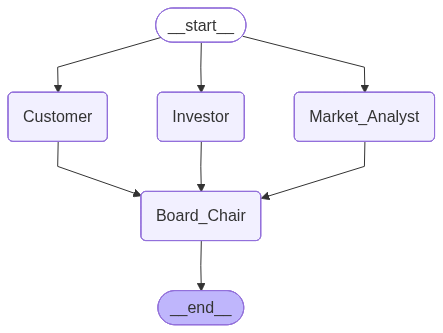

In [11]:
from IPython.display import Image, display

try:
    display(Image(virtual_board.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print("Could not visualize the graph:", e)

## 6. Run the Virtual Board (Real-World Scenario)
We define an initial startup strategy and send it through our LangGraph multi-agent system. Using `graph.stream`, we can observe the AI deliberating in real-time.

In [12]:
# Real-World Scenario: A B2B SaaS startup pivoting strategy.
startup_strategy = """
We are building an AI-powered platform that automatically generates and manages dynamic pricing for local physical retail stores (e.g., bakeries, boutique shops). 
We plan to charge a flat subscription fee of $200/month plus a 1% cut of increased revenue.
Our go-to-market primarily relies on aggressive cold-calling to store owners and offering a 30-day free trial. 
We aim to reach $1M ARR within 18 months by onboarding roughly 400 stores.
"""

print(f"Stress-Testing Strategy:\n{startup_strategy}\n")
print("="*50)
print("The Virtual Board of Advisors is convening (Streaming Process)...\n")

initial_state = {"strategy": startup_strategy}

# Stream the events to visibly show the multi-agent deliberation process
final_state = None
for event in virtual_board.stream(initial_state):
    for node_name, node_state in event.items():
        print(f"\n[Node Completed] {node_name} finished evaluating.")
        # In the final output, we don't need to print the partial states yet, 
        # but we can save the last event's data when it arrives from the Board_Chair
        final_state = node_state
        
# LangGraph sometimes returns nested outputs, so grab the dictionary containing the final answers
if "final_synthesis" not in final_state:
    # Fetch all the keys if it's returning the full BoardState
    final_state = {k: v for d in event.values() for k, v in d.items()} 
    # Adding in existing states just in case stream output missed some keys

final_state = event.get("Board_Chair", final_state)
print("\n" + "="*50 + "\n")

print("--- MARKET ANALYST ---\n")
print(final_state.get("market_analyst_feedback", "Pending...").encode('ascii', 'ignore').decode('ascii'))
print("\n" + "="*50 + "\n")

print("--- TARGET CUSTOMER ---\n")
print(final_state.get("customer_feedback", "Pending...").encode('ascii', 'ignore').decode('ascii'))
print("\n" + "="*50 + "\n")

print("--- INVESTOR ---\n")
print(final_state.get("investor_feedback", "Pending...").encode('ascii', 'ignore').decode('ascii'))
print("\n" + "="*50 + "\n")

print("--- BOARD CHAIR SYNTHESIS ---\n")
print(final_state.get("final_synthesis", "Pending...").encode('ascii', 'ignore').decode('ascii'))

Stress-Testing Strategy:

We are building an AI-powered platform that automatically generates and manages dynamic pricing for local physical retail stores (e.g., bakeries, boutique shops). 
We plan to charge a flat subscription fee of $200/month plus a 1% cut of increased revenue.
Our go-to-market primarily relies on aggressive cold-calling to store owners and offering a 30-day free trial. 
We aim to reach $1M ARR within 18 months by onboarding roughly 400 stores.


The Virtual Board of Advisors is convening (Streaming Process)...

--- Investor has completed evaluation ---

[Node Completed] Investor finished evaluating.
--- Target Customer has completed evaluation ---

[Node Completed] Customer finished evaluating.
--- Market Analyst has completed evaluation ---

[Node Completed] Market_Analyst finished evaluating.
--- Board Chair has completed synthesis ---

[Node Completed] Board_Chair finished evaluating.


--- MARKET ANALYST ---

Pending...


--- TARGET CUSTOMER ---

Pending...


-